In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
import matplotlib.pyplot as plt
import scipy.optimize as sco
import warnings
warnings.filterwarnings("ignore")

In [21]:
risk_free_rate = 0.02  # Risk free rate

In [2]:
assets = ["AAPL", "MSFT", "GOOG", "AMZN", "TSLA"]
# take 10 stocks from the S&P 500
# assets = ["AAPL", "MSFT", "GOOG", "AMZN", "TSLA", "JPM", "JNJ", "V", "PG", "UNH"] 
start_date = "2015-01-01"
end_date = "2025-01-01"
data = yf.download(assets, start=start_date, end=end_date)['Adj Close']

[*********************100%***********************]  5 of 5 completed


In [3]:
sp500 = yf.download("^GSPC", start=start_date, end=end_date)['Adj Close']
sp500_returns = sp500.pct_change()

[*********************100%***********************]  1 of 1 completed


In [ ]:
def min_volatility_weights(data):
    mu = expected_returns.mean_historical_return(data)
    S = risk_models.sample_cov(data)
    ef = EfficientFrontier(mu, S)
    weights = ef.min_volatility()
    cleaned_weights = ef.clean_weights()
    return cleaned_weights


def max_sharpe_ratio(data):
    
    
    mu = expected_returns.mean_historical_return(data)
    S = risk_models.sample_cov(data)
    num_assets = len(mu)
    
    def sharpe_ratio(weights):
        weights = np.array(weights)
        port_return = np.dot(weights, mu)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(S, weights)))
        return -(port_return - risk_free_rate) / port_volatility  # Negative for minimization
    
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})  # Sum of weights must be 1
    bounds = tuple((0, 1) for _ in range(num_assets))  # No short selling
    initial_weights = np.ones(num_assets) / num_assets  # Equal allocation start
    
    result = sco.minimize(sharpe_ratio, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    
    optimal_weights = result.x
    cleaned_weights = {asset: weight for asset, weight in zip(data.columns, optimal_weights)}
    return cleaned_weights    


def equal_weights(data):
    n = len(data.columns)
    weights = np.array([1/n for _ in range(n)])
    return dict(zip(data.columns, weights))

    


In [12]:
def backtest(data,window_length, weight_strategy):
    # start with an initial investment of 10000
    initial_investment = 10000
    portfolio_value = [initial_investment]

    data_returns = data.pct_change()
    
    # dates  = [data_returns.index[window_length - 1]]
    dates = data_returns.index[window_length - 1:]
    W = []

    for i in range(int(len(data)/window_length)):
        # get weights for the current window
        train_data = data.iloc[i * window_length: (i+1) * window_length]
        weights = weight_strategy(train_data)

        # portfolio return
        if i == int(len(data)/window_length) - 1:
            test_data = data_returns.iloc[(i+1) * window_length: ]
            # dates.extend(test_data.index.to_list())
        else:
            test_data = data_returns.iloc[(i+1) * window_length: (i + 2) * window_length]
            # dates.extend(test_data.index.to_list())
        
        portfolio_return = (weights * test_data).sum(axis=1)
        
        for j in range(len(portfolio_return)):
            portfolio_value.append(portfolio_value[-1] * (1 + portfolio_return.iloc[j]))

        W.append(weights)

    return portfolio_value, dates, W

In [17]:
window_size = 180
# backtesting the equal weighteg portfolio
equal_weights_portfolio, dates, weights_equal = backtest(data, window_size, equal_weights)

# backtesting the min volatility portfolio
min_volatility_portfolio, dates, weights_min_vol = backtest(data, window_size, min_volatility_weights)

# backtesting the max sharpe ratio portfolio
max_sharpe_portfolio, dates, weights_max_sh = backtest(data, window_size, max_sharpe_ratio)


# S&P 500 returns
sp500_investment = [10000]
sp500_dates = sp500.index[window_size - 1:]

for i in range(window_size,len(sp500)):
        sp500_investment.append(sp500_investment[-1] * (1 + sp500_returns.iloc[i]))

In [18]:
len(sp500_investment), len(sp500_dates)

(2337, 2337)

In [19]:
len(dates),len(sp500_investment)

(2337, 2337)

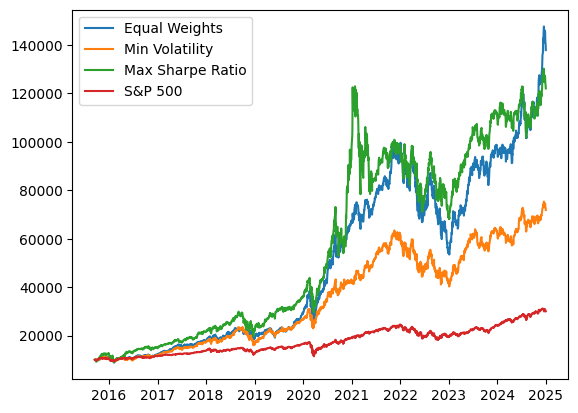

In [20]:
plt.plot(dates, equal_weights_portfolio, label="Equal Weights")
plt.plot(dates, min_volatility_portfolio, label="Min Volatility")
plt.plot(dates, max_sharpe_portfolio, label="Max Sharpe Ratio")
plt.plot(dates, sp500_investment, label="S&P 500")
plt.legend()

In [24]:
def get_sharpe_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    # print(annualized_return)
    annualized_volatility = portfolio_value.pct_change().std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / annualized_volatility

def get_sortino_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    downside_volatility = portfolio_value.pct_change()[portfolio_value.pct_change() < 0].std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / downside_volatility

def get_max_drawdown(portfolio_value):
    drawdown =  []
    peak = portfolio_value[0]

    for i in range(len(portfolio_value)):
        if portfolio_value[i] >= peak:
            peak = portfolio_value[i]
            drawdown.append(0)
        else:
            drawdown.append((portfolio_value[i] - peak) / peak)
    
    return drawdown


print(get_sharpe_ratio(pd.Series(equal_weights_portfolio, index=dates)))
print(get_sharpe_ratio(pd.Series(min_volatility_portfolio, index=dates)))
print(get_sharpe_ratio(pd.Series(max_sharpe_portfolio, index=dates)))
print(get_sharpe_ratio(pd.Series(sp500_investment, index=sp500_dates)))


1.1167825443253392
0.8618628776582246
0.8833306275078494
0.5888034775379647


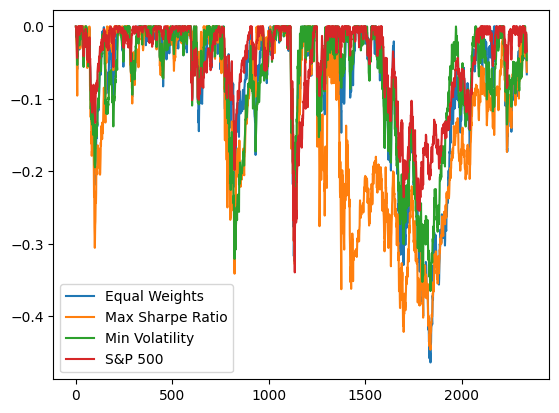

In [25]:
plt.plot(get_max_drawdown(equal_weights_portfolio), label="Equal Weights")
plt.plot(get_max_drawdown(max_sharpe_portfolio), label="Max Sharpe Ratio")
plt.plot(get_max_drawdown(min_volatility_portfolio), label="Min Volatility")
plt.plot(get_max_drawdown(sp500_investment), label="S&P 500")
plt.legend()

In [57]:
sp500_investment[-1]

19608.994461534137

In [59]:
sp500[0],sp500[-1]

(2058.199951171875, 3839.5)

In [75]:
(sp500_investment[-1] - sp500_investment[0]) / sp500_investment[0]

2.0038507044371316